# Reading a FRET network as a picture

A single FRET measurement is one distance between two labelled positions. A
*network* is many of them on the same molecule: ten, twenty, sometimes a
hundred pairs of sites, each with its own donor, its own acceptor, its own
uncertainty. The network is what turns FRET from a ruler into a structural
method, because no single distance pins a structure and twenty of them,
spread over the molecule, can.

The problem is reading one. A network of eighteen pairs is a table of eighteen
rows of measured distance, modelled distance, difference and uncertainty. A
table is fine for looking up one number and useless for the question you
actually have, which is *where* the model and the measurements disagree. Is the
disagreement everywhere, which means the model is simply the wrong state? Is it
in one domain, which means that domain is placed wrong? Is it on the chords
that touch one particular site, which usually means that site's label is
behaving badly and the model is innocent?

The circle plot answers that question by putting geometry back into the
picture:

* every labelled **site** is a point on the rim, ordered so that sites that
  belong together sit together -- here, by protomer and by domain;
* every **measured pair** is a chord between its two sites;
* the **colour** of the chord is the signed deviation, modelled minus measured,
  in Angstrom: red where the model is too long, blue where it is too short,
  pale where it agrees;
* the **thickness** of the chord is the same deviation measured in standard
  deviations of the experiment -- how *significant* the disagreement is, not
  how large it is in Angstrom.

Colour and thickness deliberately carry different things. A 10 A miss on a
pair measured to +-15 A is pale-ish and thin; a 4 A miss on a pair measured to
+-1 A is pale and thick. The eye picks out the thick chords, which are the ones
worth arguing about.

What this notebook does: build an eighteen-pair network on the ABC transporter
BmrA, invent a set of measurements from one of its two known conformations,
score the *other* conformation against them, and then look at the same numbers
three ways -- as a table, as a circle, and as a scatter.

## Setup

`workshop.py` next to this notebook holds the pieces every notebook in this
series shares: fetching and trimming the two BmrA structures, the accessible
volume call with the dye geometries filled in, and the circle plot itself. The
structures are cached in `_data/`, so this runs offline after the first time.

In [1]:
%matplotlib inline
import sys, pathlib, time
sys.path.insert(0, str(pathlib.Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.spatial import cKDTree

import workshop as ws

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.3})

t_start = time.time()
closed_pdb = ws.single_dimer("closed")   # 6R72, outward facing, NBDs together
open_pdb = ws.single_dimer("open")       # 8QOE, inward facing, NBDs apart
print("closed:", closed_pdb.name, "--", ws.STATES["closed"]["note"])
print("open:  ", open_pdb.name, "--", ws.STATES["open"]["note"])
print("Forster radius of the Alexa488/Alexa647 pair, R0 =", ws.R0, "A")

closed: BmrA_closed.pdb -- outward-facing, E504A, ATP/Mg (X-ray)
open:   BmrA_open.pdb -- inward-facing (cryo-EM)
Forster radius of the Alexa488/Alexa647 pair, R0 = 52.0 A


## The network

BmrA is a homodimer, and each protomer is one transmembrane domain (TMD, here
residues below 330) welded to one nucleotide-binding domain (NBD, above 330).
The two protomers close their NBDs against each other to hydrolyse ATP and open
them again to take up substrate. That is the motion a FRET network is being
asked to see, so every pair below is **inter-protomer**: donor on chain A,
acceptor on chain B. An intra-protomer pair would mostly report on the part
that does not move.

Eight positions are used per protomer, five in the TMD and three in the NBD.
They were chosen by scanning the sequence for positions where the dye actually
has somewhere to go in both structures -- a buried position gives an empty
accessible volume and therefore no distance at all, not a distance of zero --
and then keeping the pairs whose distance lands in the range a
Alexa488/Alexa647 experiment can measure, roughly 30 to 85 A for an R0 of 52 A.

In [2]:
# (donor site on chain A, acceptor site on chain B)
PAIRS = [
    (("A",  51), ("B",  51)), (("A", 105), ("B", 105)), (("A", 105), ("B", 195)),
    (("A", 141), ("B",  51)), (("A", 141), ("B", 261)), (("A", 195), ("B",  51)),
    (("A", 261), ("B", 195)), (("A", 261), ("B", 261)), (("A", 261), ("B", 105)),
    (("A", 351), ("B", 141)), (("A", 351), ("B", 447)), (("A", 351), ("B", 351)),
    (("A", 447), ("B", 195)), (("A", 447), ("B", 141)), (("A", 519), ("B", 519)),
    (("A", 519), ("B", 447)), (("A", 195), ("B", 519)), (("A", 105), ("B", 351)),
]

NBD_FROM = 330          # residues at or above this number are in the NBD
DONOR, ACCEPTOR = "Alexa488", "Alexa647"

def label(site):
    return f"{site[0]}{site[1]}"

def domain(site):
    return "NBD" if site[1] >= NBD_FROM else "TMD"

SITES = []
for a, b in PAIRS:
    for s in (a, b):
        if s not in SITES:
            SITES.append(s)
SITES.sort(key=lambda s: (s[0], s[1]))

print(f"{len(PAIRS)} pairs over {len(SITES)} sites")
for chain in ("A", "B"):
    for dom in ("TMD", "NBD"):
        members = [label(s) for s in SITES if s[0] == chain and domain(s) == dom]
        print(f"  chain {chain} {dom}: {', '.join(members)}")

18 pairs over 16 sites
  chain A TMD: A51, A105, A141, A195, A261
  chain A NBD: A351, A447, A519
  chain B TMD: B51, B105, B141, B195, B261
  chain B NBD: B351, B447, B519


### The modelled distances

For every site the accessible volume of its dye is computed on the structure,
and for every pair the two volumes are reduced to one number. That number is
`<R_DA>_E`, the distance that reproduces the mean transfer efficiency of the
pair. It is not the mean of the distance distribution: for two broad volumes
the two differ by several Angstrom, and `<R_DA>_E` is what an efficiency
measurement actually reports.

In [3]:
def volumes(pdb_path):
    "The accessible volume of every site in the network, on one structure."
    out = {}
    for site in SITES:
        dye = DONOR if site[0] == "A" else ACCEPTOR
        out[site] = ws.av(pdb_path, site[0], site[1], dye=dye)
    return out

t0 = time.time()
AV = {"closed": volumes(closed_pdb), "open": volumes(open_pdb)}
print(f"{2 * len(SITES)} accessible volumes in {time.time() - t0:.1f} s")

def network(av_of_state):
    return {p: ws.rda_e(av_of_state[p[0]], av_of_state[p[1]]) for p in PAIRS}

d_closed = network(AV["closed"])
d_open = network(AV["open"])

32 accessible volumes in 0.5 s


## The table, so you can see the problem

Here is the whole network as numbers. Both columns are modelled: what the
closed structure predicts and what the open structure predicts, for the same
eighteen pairs.

Look at it for a moment and try to answer: which part of the molecule moves
between the two states, and which pairs would tell the two apart? The answer is
in the table. Extracting it by eye takes a minute or two of careful reading,
and this is a small network measured without error.

In [4]:
print(f"{'pair':>14}  {'closed':>8}  {'open':>8}  {'open-closed':>12}")
print("-" * 48)
for p in PAIRS:
    name = f"{label(p[0])}-{label(p[1])}"
    print(f"{name:>14}  {d_closed[p]:8.1f}  {d_open[p]:8.1f}  {d_open[p]-d_closed[p]:+12.1f}")

          pair    closed      open   open-closed
------------------------------------------------
       A51-B51      35.9      45.0          +9.1
     A105-B105      61.4      84.3         +22.9
     A105-B195      38.0      43.8          +5.8
      A141-B51      52.8      49.3          -3.5
     A141-B261      53.8      34.5         -19.3
      A195-B51      61.5      48.3         -13.2
     A261-B195      67.9      38.6         -29.3
     A261-B261      69.6      45.9         -23.8
     A261-B105      59.6      55.4          -4.2
     A351-B141      66.1      51.0         -15.0
     A351-B447      43.0      62.0         +19.0
     A351-B351      63.4      65.9          +2.4
     A447-B195      42.0      63.7         +21.7
     A447-B141      74.3      69.5          -4.8
     A519-B519      51.4      55.3          +3.9
     A519-B447      65.6      75.6         +10.1
     A195-B519      55.9      67.1         +11.2
     A105-B351      51.9      66.4         +14.5


## The measurements are synthetic

**Everything called "measured" below is invented.** There is no BmrA FRET data
set in this notebook. The measurements are the open-state modelled distances
with 6 per cent Gaussian noise added, and the quoted uncertainty is 6 per cent
of the measured value.

That is a deliberate choice, and it is worth being explicit about what it buys
and what it hides.

What it buys: a ground truth. Because the measurements were generated from the
open state, we know exactly which structure should fit and by how much, so the
figures below can be checked rather than believed. With real data you never get
that, and a notebook that teaches you to read a figure had better let you check
that you read it right.

What it hides: every systematic error a real network has. Six per cent
Gaussian noise on `<R_DA>_E` is roughly the scatter a careful ensemble or
single-molecule experiment reaches on a well-behaved pair, but real networks
also carry dyes that stick to the surface, sites whose labelling changes the
fold, uncertain Forster radii, and conformational mixtures that no single
structure can satisfy. None of that is in here. The last section says what
those failures look like in this figure, which is the part of the lesson the
synthetic data cannot demonstrate.

In [5]:
NOISE = 0.06                                  # relative, on <R_DA>_E
rng = np.random.default_rng(20240917)         # fixed, so the notebook repeats

measured = {p: d_open[p] * (1.0 + NOISE * rng.standard_normal()) for p in PAIRS}
sigma = {p: NOISE * measured[p] for p in PAIRS}

def chi2_red(model):
    "Reduced chi-squared of a set of modelled distances against the network."
    terms = [((model[p] - measured[p]) / sigma[p]) ** 2 for p in PAIRS]
    return float(np.sum(terms) / len(PAIRS))

def deviation(model):
    "model - measured, in Angstrom."
    return {p: model[p] - measured[p] for p in PAIRS}

def significance(model):
    "|model - measured| in units of the experimental uncertainty."
    return {p: abs(model[p] - measured[p]) / sigma[p] for p in PAIRS}

print(f"{'pair':>14}  {'measured':>10}  {'+-':>5}   {'E':>5}")
print("-" * 42)
for p in PAIRS:
    name = f"{label(p[0])}-{label(p[1])}"
    print(f"{name:>14}  {measured[p]:10.1f}  {sigma[p]:5.1f}   {ws.efficiency(measured[p]):5.2f}")

          pair    measured     +-       E
------------------------------------------
       A51-B51        45.4    2.7    0.69
     A105-B105        82.6    5.0    0.06
     A105-B195        41.9    2.5    0.78
      A141-B51        52.1    3.1    0.50
     A141-B261        31.9    1.9    0.95
      A195-B51        50.5    3.0    0.54
     A261-B195        40.5    2.4    0.82
     A261-B261        44.8    2.7    0.71
     A261-B105        47.6    2.9    0.63
     A351-B141        59.2    3.6    0.31
     A351-B447        60.3    3.6    0.29
     A351-B351        64.1    3.8    0.22
     A447-B195        69.4    4.2    0.15
     A447-B141        73.0    4.4    0.12
     A519-B519        48.4    2.9    0.61
     A519-B447        78.3    4.7    0.08
     A195-B519        70.5    4.2    0.14
     A105-B351        66.3    4.0    0.19


## Before: the wrong state scored against the network

The closed structure is now scored against the eighteen synthetic
measurements. It is the wrong answer by construction, and the numbers say so
loudly.

In [6]:
print(f"reduced chi2, closed model vs measurements: {chi2_red(d_closed):6.1f}")
print(f"reduced chi2, open model vs measurements:   {chi2_red(d_open):6.2f}")
print()

dev_closed, sig_closed = deviation(d_closed), significance(d_closed)
worst = sorted(PAIRS, key=lambda p: -sig_closed[p])
print("the five pairs the closed model gets most wrong:")
for p in worst[:5]:
    name = f"{label(p[0])}-{label(p[1])}"
    print(f"  {name:>14}  measured {measured[p]:5.1f} +- {sigma[p]:4.1f} A, "
          f"model {d_closed[p]:5.1f} A  ->  {dev_closed[p]:+6.1f} A "
          f"({sig_closed[p]:4.1f} sigma)")
print()
print("the three it gets right:")
for p in worst[-3:]:
    name = f"{label(p[0])}-{label(p[1])}"
    print(f"  {name:>14}  measured {measured[p]:5.1f} +- {sigma[p]:4.1f} A, "
          f"model {d_closed[p]:5.1f} A  ->  {dev_closed[p]:+6.1f} A "
          f"({sig_closed[p]:4.1f} sigma)")

reduced chi2, closed model vs measurements:   28.3
reduced chi2, open model vs measurements:     1.49

the five pairs the closed model gets most wrong:
       A141-B261  measured  31.9 +-  1.9 A, model  53.8 A  ->   +21.9 A (11.4 sigma)
       A261-B195  measured  40.5 +-  2.4 A, model  67.9 A  ->   +27.4 A (11.3 sigma)
       A261-B261  measured  44.8 +-  2.7 A, model  69.6 A  ->   +24.8 A ( 9.2 sigma)
       A447-B195  measured  69.4 +-  4.2 A, model  42.0 A  ->   -27.4 A ( 6.6 sigma)
       A351-B447  measured  60.3 +-  3.6 A, model  43.0 A  ->   -17.3 A ( 4.8 sigma)

the three it gets right:
       A447-B141  measured  73.0 +-  4.4 A, model  74.3 A  ->    +1.3 A ( 0.3 sigma)
        A141-B51  measured  52.1 +-  3.1 A, model  52.8 A  ->    +0.7 A ( 0.2 sigma)
       A351-B351  measured  64.1 +-  3.8 A, model  63.4 A  ->    -0.6 A ( 0.2 sigma)


### Before and after, on one colour scale

Two circle plots: the closed model on the left, the open model on the right,
against the same measurements.

The colour scale is fixed once, from the largest deviation in either panel, and
both panels use it. This matters more than it sounds. Letting each panel pick
its own scale makes the right panel's residual noise look exactly as alarming
as the left panel's 27 A errors, and the comparison the figure exists to make
becomes a lie. One `vmax`, one colour bar.

colour scale: +-27 A, shared by every circle plot below


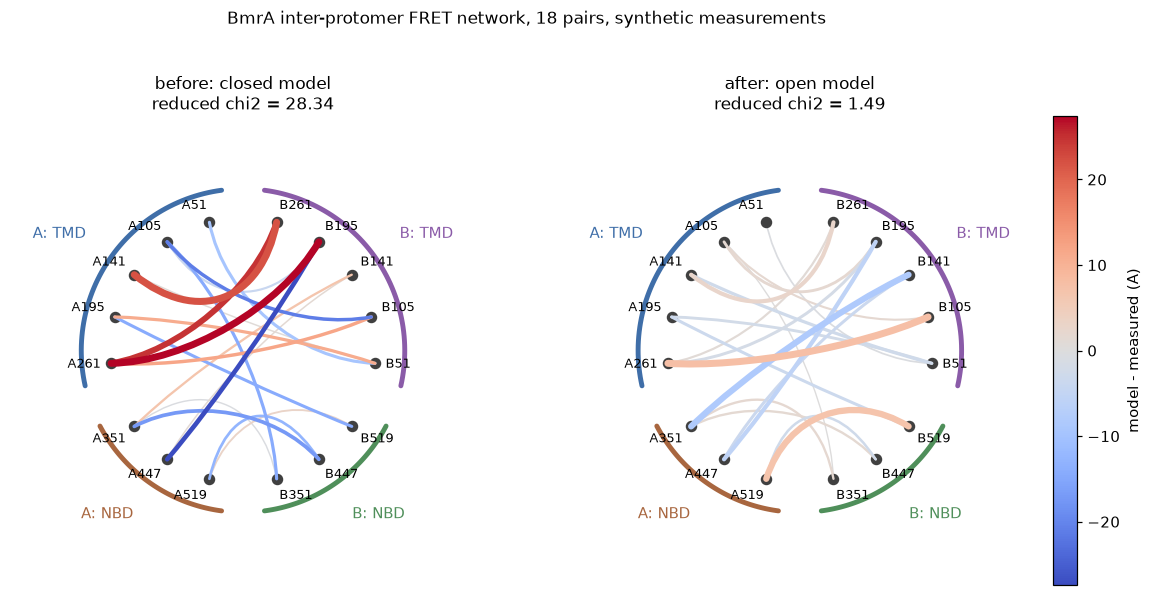

In [7]:
GROUPS = {site: f"{site[0]}: {domain(site)}" for site in SITES}
ORDER = [s for s in SITES if s[0] == "A" and domain(s) == "TMD"] + \
        [s for s in SITES if s[0] == "A" and domain(s) == "NBD"] + \
        [s for s in SITES if s[0] == "B" and domain(s) == "NBD"] + \
        [s for s in SITES if s[0] == "B" and domain(s) == "TMD"]

dev_open, sig_open = deviation(d_open), significance(d_open)

# One scale for every circle plot in this notebook, set by the worst panel.
VMAX = max(max(abs(v) for v in dev_closed.values()),
           max(abs(v) for v in dev_open.values()))
print(f"colour scale: +-{VMAX:.0f} A, shared by every circle plot below")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.0))
for ax, (dev, sig, name, model) in zip(axes, [
        (dev_closed, sig_closed, "before: closed model", d_closed),
        (dev_open, sig_open, "after: open model", d_open)]):
    ws.circle_plot(PAIRS, dev, ax=ax, vmax=VMAX, widths=sig,
                   groups=GROUPS, order=ORDER, label_fmt=label, colorbar=False,
                   title=f"{name}\nreduced chi2 = {chi2_red(model):.2f}")
bar = fig.colorbar(ws.deviation_mappable(VMAX), ax=axes, fraction=0.022, pad=0.02)
bar.set_label("model - measured (A)")
fig.suptitle("BmrA inter-protomer FRET network, 18 pairs, synthetic measurements",
             y=1.01, fontsize=11)
plt.show()

### What the left panel says

Three things come off it without reading a single number.

**The whole circle is coloured, not one corner of it.** Every arc on the rim
carries thick chords. A model that is only slightly misplaced in one place
gives a figure with one or two hot chords and a pale remainder. This is not
that: it is the signature of the wrong conformation, not of a local error.

**Both signs are present, and they sort themselves by where the sites are.**
Five chords are drawn thickest, which means the experiment cannot explain them
away, and they split cleanly. Three are red and stay inside the transmembrane
group, running between positions 141, 195 and 261: the closed model puts those
22 to 27 A too far apart, which is 9 to 11 standard deviations. Two are blue
and have one end on a nucleotide-binding site, A447-B195 and A351-B447: too
short by 27 and 17 A. A model that is merely imprecise has no reason to arrange
its errors by which sites they touch. A model that is in the wrong conformation
does, because the two conformations differ by one concerted motion and each
chord samples a different component of it. The single number, reduced chi2 of
28, says none of this, and the table yields it only after a minute of
arithmetic. The rim ordering is what makes it visible: grouping the sites by
protomer and domain puts the chords that share a cause next to each other.

**Two chords stay pale in both panels.** A141-B51 and the NBD-NBD chord
A351-B351 change by under 4 A between the two conformations, so the wrong model
scores them within a fifth of a standard deviation. They are perfectly good
measurements and they carry no information about *this* question. In a real
experiment they are the pairs you stop paying for.

The right panel is what agreement looks like: pale, thin, no structure. The
residual colour is the 6 per cent noise, nothing more. "No structure" is the
thing to check -- if the right panel were pale everywhere except for three
thick chords on one site, the model would be good and that site would be the
problem.

## What a cheap optimisation buys, and what it does not

Handing a reader the correct structure is not an analysis. The honest version
of "after" is a model that was *fitted* to the measurements. So: take the wrong
starting structure, keep protomer A where it is, and let protomer B move as a
rigid body -- three rotations and three translations -- to fit the eighteen
distances.

Two things about this refinement should be said before its result is shown.

It is done on the dye clouds, not on the protein. The accessible volumes of
chain B are computed once on the closed structure and then rotated and
translated as a rigid set of points. This means the volumes are never
recomputed in the new surroundings, so the refined model does not know that a
dye which was blocked by a helix in the starting structure might be free in the
fitted one. For a modest move that approximation is mild; for a large one it is
not, and the move this fit makes is large.

Nothing keeps the two protomers apart. There is no steric term in the target
function, only the eighteen distances. Whether the answer is a physically
possible arrangement of two protein chains is not something the fit checks, so
we check it afterwards.

The distance calculation inside the optimiser is a plain numpy re-implementation
of `<R_DA>_E` on thinned clouds, because it has to run a few hundred times. The
cell below checks it against `ws.rda_e` first, so the fit is not being scored on
a quantity that differs from the one being plotted.

In [8]:
def thin(points, n=250):
    "A fixed-stride subset of a cloud: enough for a distance, cheap enough to fit."
    return points if len(points) <= n else points[np.linspace(0, len(points) - 1, n).astype(int)]

def rda_e_numpy(a, b, forster_radius=ws.R0):
    "<R_DA>_E from two weighted point clouds, written out in full."
    d = np.linalg.norm(a[:, None, :3] - b[None, :, :3], axis=-1)
    w = np.outer(a[:, 3], b[:, 3])
    w = w / w.sum()
    e = float((w / (1.0 + (d / forster_radius) ** 6)).sum())
    return forster_radius * ((1.0 - e) / e) ** (1.0 / 6.0)

cloud = {state: {s: ws.av_points(AV[state][s]) for s in SITES} for state in ("closed", "open")}
check = PAIRS[6]
print(f"check on {label(check[0])}-{label(check[1])} in the closed state:")
print(f"  ws.rda_e (full clouds, C++) : {d_closed[check]:7.3f} A")
print(f"  numpy    (full clouds)      : "
      f"{rda_e_numpy(cloud['closed'][check[0]], cloud['closed'][check[1]]):7.3f} A")
print(f"  numpy    (thinned to 250)   : "
      f"{rda_e_numpy(thin(cloud['closed'][check[0]]), thin(cloud['closed'][check[1]])):7.3f} A")

check on A261-B195 in the closed state:
  ws.rda_e (full clouds, C++) :  67.923 A
  numpy    (full clouds)      :  67.992 A
  numpy    (thinned to 250)   :  68.057 A


In [9]:
A_cloud = {s: thin(cloud["closed"][s]) for s in SITES if s[0] == "A"}
B_cloud = {s: thin(cloud["closed"][s]) for s in SITES if s[0] == "B"}
pivot = np.mean(np.vstack([v[:, :3] for v in B_cloud.values()]), axis=0)

def rotation(v):
    "Rodrigues: a rotation vector (axis * angle, radians) as a 3x3 matrix."
    angle = float(np.linalg.norm(v))
    if angle < 1e-12:
        return np.eye(3)
    k = np.asarray(v) / angle
    K = np.array([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]])
    return np.eye(3) + np.sin(angle) * K + (1.0 - np.cos(angle)) * (K @ K)

def place(par, xyz):
    return (xyz - pivot) @ rotation(par[:3]).T + pivot + par[3:]

def model_for(par):
    moved = {s: np.column_stack([place(par, v[:, :3]), v[:, 3]]) for s, v in B_cloud.items()}
    return {p: rda_e_numpy(A_cloud[p[0]], moved[p[1]]) for p in PAIRS}

def target(par):
    return chi2_red(model_for(par))

t0 = time.time()
fit = minimize(target, np.zeros(6), method="Powell",
               options={"maxiter": 200, "xtol": 1e-3, "ftol": 1e-4})
d_fit = model_for(fit.x)
print(f"{fit.nfev} evaluations in {time.time() - t0:.0f} s")
print(f"reduced chi2   start (closed) {chi2_red(d_closed):6.1f}"
      f"   fitted {chi2_red(d_fit):6.2f}"
      f"   true state (open) {chi2_red(d_open):6.2f}")
print(f"the move it made: {np.linalg.norm(fit.x[3:]):.0f} A of translation, "
      f"{np.degrees(np.linalg.norm(fit.x[:3])):.0f} degrees of rotation")

425 evaluations in 18 s
reduced chi2   start (closed)   28.3   fitted   5.35   true state (open)   1.49
the move it made: 17 A of translation, 48 degrees of rotation


In [10]:
def c_alphas(pdb_path, chain):
    xyz = []
    for line in pathlib.Path(pdb_path).read_text().splitlines():
        if line.startswith("ATOM") and line[12:16].strip() == "CA" and line[21] == chain:
            xyz.append([float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return np.asarray(xyz)

ca_a = c_alphas(closed_pdb, "A")
ca_b = c_alphas(closed_pdb, "B")
tree = cKDTree(ca_a)
before_gap = tree.query(ca_b)[0].min()
after_gap = tree.query(place(fit.x, ca_b))[0].min()
clashing = int((tree.query(place(fit.x, ca_b))[0] < 4.0).sum())
print(f"closest C-alpha between the protomers, starting structure: {before_gap:5.1f} A")
print(f"closest C-alpha between the protomers, fitted placement:   {after_gap:5.1f} A")
print(f"C-alphas of chain B inside 4 A of chain A after the fit:    {clashing}")

closest C-alpha between the protomers, starting structure:   4.5 A
closest C-alpha between the protomers, fitted placement:     0.5 A
C-alphas of chain B inside 4 A of chain A after the fit:    96


The fit does what it was asked to do: the reduced chi-squared falls by most of
the way from the starting value towards the value the true structure achieves.
And the model it produces is impossible. The two protomers interpenetrate --
scores of backbone atoms end up inside each other -- because the target
function contained eighteen distances and no chemistry.

The deeper reason it cannot reach the true structure is that the motion it is
allowed to make is the wrong motion. BmrA's closed-to-open transition is not a
rigid re-placement of one protomer against the other; it is a hinge *inside*
each protomer, between its transmembrane and nucleotide-binding domains. Six
rigid-body parameters cannot express that, so the fit spends them buying the
largest chi-squared reduction available, and that happens to be a shove that
collides the chains. The circle plot below is how you see this, rather than
being told it.

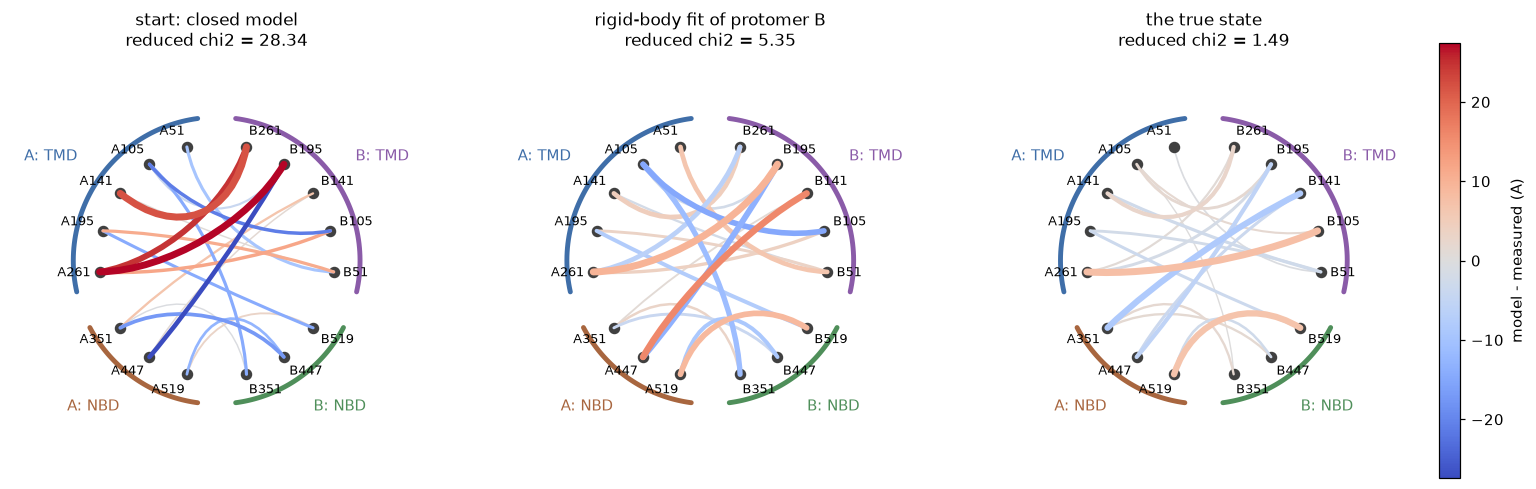

In [11]:
dev_fit, sig_fit = deviation(d_fit), significance(d_fit)

fig, axes = plt.subplots(1, 3, figsize=(17.0, 6.0))
panels = [(dev_closed, sig_closed, "start: closed model", d_closed),
          (dev_fit, sig_fit, "rigid-body fit of protomer B", d_fit),
          (dev_open, sig_open, "the true state", d_open)]
for ax, (dev, sig, name, model) in zip(axes, panels):
    ws.circle_plot(PAIRS, dev, ax=ax, vmax=VMAX, widths=sig,
                   groups=GROUPS, order=ORDER, label_fmt=label, colorbar=False,
                   title=f"{name}\nreduced chi2 = {chi2_red(model):.2f}")
bar = fig.colorbar(ws.deviation_mappable(VMAX), ax=axes, fraction=0.015, pad=0.02)
bar.set_label("model - measured (A)")
plt.show()

The middle panel is the useful one, and it is useful because of what it did
*not* fix. The fit has drained the colour out of the extremes, which is why
chi-squared fell from 28 to 5. What is left is not the noise floor of the right
panel: half the chords are still 2 to 4 standard deviations out, in both
signs, and they are spread right across the circle rather than sitting in one
place. There is no arc you can point to and say "that domain is the problem",
because the rigid body has paid for its improvement everywhere at once, taking
a little from each large deviation and adding some to the small ones.

The clearest evidence of that trade is one chord. A447-B141 is a pair the
*starting* model already got right, within 0.3 standard deviations, and the fit
pushes it to 3.7. A fit with too few degrees of freedom will sacrifice the
measurements it was already satisfying in order to reduce the ones it was not,
and the circle plot shows you which ones were sacrificed. A chi-squared of 5
tells you only that something is left over.

That is the pattern to learn. A residual that is *spread* after a fit means the
model is missing a degree of freedom the data want, not that the data are bad.
A residual that is *concentrated* after a fit means one part of the model, or
one part of the data, is wrong on its own.

## The companion figure the circle cannot replace

The circle plot throws away one thing: the distances themselves. Every chord is
coloured by a deviation, so a 2 A error on a 35 A pair and a 2 A error on an
80 A pair look identical, and you cannot see from the circle that the second
one is a much easier measurement in relative terms and a much harder one in
absolute terms, because transfer efficiency is flat out there.

So the circle plot always travels with a scatter: measured against modelled,
one point per pair, with the experimental error bar drawn. The identity line is
the perfect model. This is the view that tells you the range of the network,
whether the disagreement grows with distance -- which would point at the
Forster radius or at the efficiency calibration rather than at the structure --
and whether the error bars are honest.

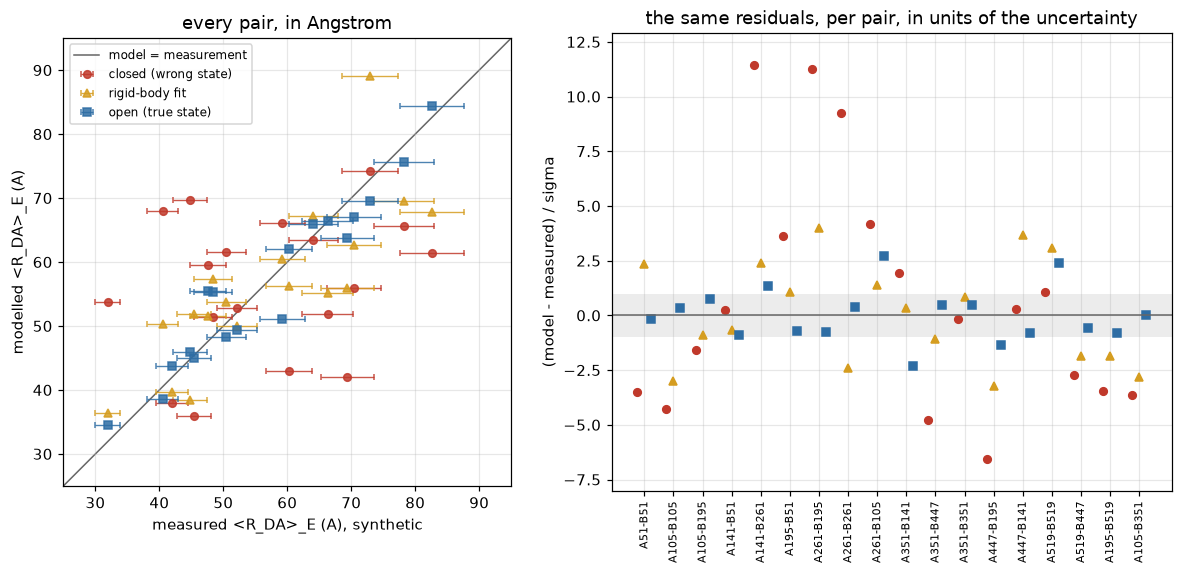

root-mean-square deviation over the network, in A:
  closed (wrong state)     15.6
  rigid-body fit            8.4
  open (true state)         3.9


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4),
                         gridspec_kw={"width_ratios": [1.0, 1.25]})

ax = axes[0]
x = np.array([measured[p] for p in PAIRS])
xerr = np.array([sigma[p] for p in PAIRS])
series = [("closed (wrong state)", d_closed, "#c0392b", "o"),
          ("rigid-body fit", d_fit, "#d59d20", "^"),
          ("open (true state)", d_open, "#2e6da4", "s")]
span = [25, 95]
ax.plot(span, span, "-", color="0.4", lw=1.0, zorder=0, label="model = measurement")
for name, model, colour, marker in series:
    y = np.array([model[p] for p in PAIRS])
    ax.errorbar(x, y, xerr=xerr, fmt=marker, ms=5, color=colour, ecolor=colour,
                elinewidth=0.9, capsize=2, alpha=0.85, ls="none", label=name)
ax.set_xlim(*span); ax.set_ylim(*span); ax.set_aspect("equal")
ax.set_xlabel("measured <R_DA>_E (A), synthetic")
ax.set_ylabel("modelled <R_DA>_E (A)")
ax.set_title("every pair, in Angstrom")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
names = [f"{label(p[0])}-{label(p[1])}" for p in PAIRS]
idx = np.arange(len(PAIRS))
for offset, (name, model, colour, marker) in zip((-0.24, 0.0, 0.24), series):
    r = np.array([(model[p] - measured[p]) / sigma[p] for p in PAIRS])
    ax.plot(idx + offset, r, marker, ms=5, color=colour, ls="none", label=name)
ax.axhline(0, color="0.4", lw=1.0)
ax.axhspan(-1, 1, color="0.5", alpha=0.15, lw=0)
ax.set_xticks(idx); ax.set_xticklabels(names, rotation=90, fontsize=7.5)
ax.set_ylabel("(model - measured) / sigma")
ax.set_title("the same residuals, per pair, in units of the uncertainty")
ax.margins(y=0.08)   # the left panel's legend serves both
plt.show()

print("root-mean-square deviation over the network, in A:")
for name, model, _, _ in series:
    r = np.array([model[p] - measured[p] for p in PAIRS])
    print(f"  {name:<22} {np.sqrt((r ** 2).mean()):6.1f}")

The grey band in the right-hand panel is one standard deviation. A model that
fits sits inside it about two thirds of the time and strays outside the rest --
that is what the blue squares do, which is the whole content of the statement
"reduced chi2 = 1.5". The red circles reach eleven standard deviations, and
those are the chords the circle plot drew thickest.

The left panel adds something the circle plot genuinely cannot show: how the
disagreement behaves as a function of distance. Here the blue squares fan out
from the identity line in proportion to the distance, and the error bars widen
in the same proportion, which is what a flat 6 per cent uncertainty looks like
and is true here only because that is how the data were generated. In a real
network this panel is where you check that claim. Points that fan out faster
than their bars mean the far pairs are less reliable than the quoted errors
say, and every chi-squared computed from that network is then wrong. Points
that drift consistently to one side of the line at long distance, but not at
short, usually mean the Forster radius is off rather than the structure.

Both panels are the same eighteen numbers as the circle. The scatter is better
at magnitudes and at spotting a trend with distance. The circle is better at
*where*, and "where" is the question that changes what you do next.

## What to look for when the data are real

With a real network and a real model, three patterns in the circle plot mean
three different things, and telling them apart is most of the skill.

**Colour everywhere, no pattern in the sign.** The model is the wrong
conformation, or the sample is a mixture of conformations and no single
structure can satisfy the network. Check the efficiency histograms for two
populations before you touch the structure.

**Colour concentrated on the chords that cross one domain boundary, with a
consistent sign.** The domains are individually right and their relative
placement is wrong. This is the case a structural refinement is actually good
at, and the chords that stay pale tell you which parts of the model to hold
fixed while you refine.

**Several bad chords, all touching one site, with the rest of the circle
pale.** This is almost never the model. A site whose every chord is off in the
same direction is a site whose dye is not behaving: stuck to the surface so its
mean position is pulled towards the protein and every distance from it comes
out short, or pushed out by a bad linker so every distance comes out long, or
simply mislabelled in the spreadsheet. The circle plot makes this diagnosis
easy, because a genuine structural error has no reason to respect the site
boundaries the way a labelling error does, and the rim ordering puts all of one
site's chords next to each other.

The practical consequence: when one site is the culprit, the fix is to redo
that site's controls -- anisotropy, the quantum yield, the accessible volume
parameters for that linker -- not to add a restraint or loosen the model. Drop
the site from the network, refit, and see whether the rest of the circle was
ever really in disagreement. If it snaps into place, you had a labelling
problem wearing a structural problem's clothes.

One last thing the figures here cannot show, because the data are synthetic:
in a real network the uncertainty is not 6 per cent of every distance. It
varies by an order of magnitude across the pairs, because some pairs sit near
R0 where efficiency is steep and informative and others sit far out where it is
flat. That is precisely why the chord thickness carries sigma rather than
Angstrom. On real data the circle plot's thick chords are frequently not its
most colourful ones.

In [13]:
print(f"notebook runtime: {time.time() - t_start:.0f} s")

notebook runtime: 19 s
